## KC velocity

In [2]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
import scvelo as scv
import scipy as sp
from pyannotables import tables

In [3]:
import sys
from pathlib import Path

In [4]:
sys.path.append(str(Path.home() / 'Code/sctoolkit'))

In [5]:
from sctoolkit.utils import bin_pval, run_spring, sort_by_correlation, dotplot_spring
from sctoolkit.proportions import plot_proportion_barplot, merge_ggplots
from harmony import harmonize

In [6]:
t = tables()
t = t['homo_sapiens-GRCh38-ensembl84'][['gene_name', 'gene_biotype']]
t = t[t.gene_biotype == 'protein_coding'].drop_duplicates(ignore_index=True).set_index('gene_name')

In [7]:
%config InlineBackend.figure_format = 'retina'

In [8]:
sc.set_figure_params(dpi=100)

In [72]:
kera = sc.read('Keratinocytes-with-harmonized-neighbors-NIKE.h5ad')
kera.var = kera.var.join(t, how='left')
#kera = kera[kera.obs.disease_lesional == 'Lesional'].copy()
#kera = kera[~kera.obs.ind_id.isin(['BCH01', 'BCH04', 'BCH07'])].copy()
kera = kera[kera.obs['Cell type granular'].isin(['Keratinocyte 5', 'Cornified keratinocytes 1', 'Cornified keratinocytes 2'])].copy()
#kera = kera[kera.obs['Cell type granular'].isin(['Cornified keratinocytes 1', 'Cornified keratinocytes 2']) | ((kera.obs.disease_lesional == 'Lesional') & (kera.obs['Cell type granular'] == 'Keratinocyte 5'))].copy() #worked

kera

AnnData object with n_obs × n_vars = 3192 × 29991
    obs: '10x_cell_calling', 'G2M_score', 'S_score', 'barcode_rank', 'chemistry_10x', 'disease_status', 'empty_drops_FDR', 'ind_id', 'lesional', 'log10_n_genes', 'log10_n_umis', 'mito_cutoff_', 'mt_frac', 'n_counts', 'n_genes', 'n_umis', 'neg_log10_empty_drops_FDR', 'phase', 'predicted_cell_types', 'predicted_sex', 'raw', 'sample_name', 'scrublet', 'scrublet_score', 'sex', 'disease_lesional', 'batch', 'leiden', 'Cell type', 'Cell type granular', 'ind_sample', 'channel', 'barcode', 'subject_id', 'global_disease_assessment', 'ad_family_history', 'sex_clinical', 'childbearing_potential', 'ethnicity_race', 'smoking', 'asthma', 'other_condition', 'systemic_corticosteroids', 'topical_corticosteroids', 'dupilumab', 'dupilumab_indication', 'dupilumab_other_indication', 'location', 'side', 'Disease score (MADAD Immune)', 'Disease score (MADAD Full)', 'Disease score (MADAD Union)', 'Cell type new cornified', 'dpt_pseudotime'
    var: 'highly_vari

In [73]:
#kera = kera[:, kera.var.gene_biotype == 'protein_coding'].copy()

In [74]:
del kera.uns['iroot']

In [114]:
sc.pp.highly_variable_genes(kera, n_top_genes=500)
sc.pp.pca(kera)
kera.obsm['X_harmony'] = harmonize(kera.obsm['X_pca'], kera.obs, 'ind_id')
sc.pp.neighbors(kera, use_rep='X_harmony', n_neighbors=150)
#sc.pp.neighbors(kera, n_neighbors=50) #worked
sc.tl.umap(kera)

	Initialization is completed.
	Completed 1 / 10 iteration(s).
	Completed 2 / 10 iteration(s).
	Completed 3 / 10 iteration(s).
	Completed 4 / 10 iteration(s).
	Completed 5 / 10 iteration(s).
	Completed 6 / 10 iteration(s).
	Completed 7 / 10 iteration(s).
	Completed 8 / 10 iteration(s).
	Completed 9 / 10 iteration(s).
	Completed 10 / 10 iteration(s).


In [115]:
#del kera.uns['Cell type granular_colors']

In [116]:
sc.tl.leiden(kera, resolution=1.)

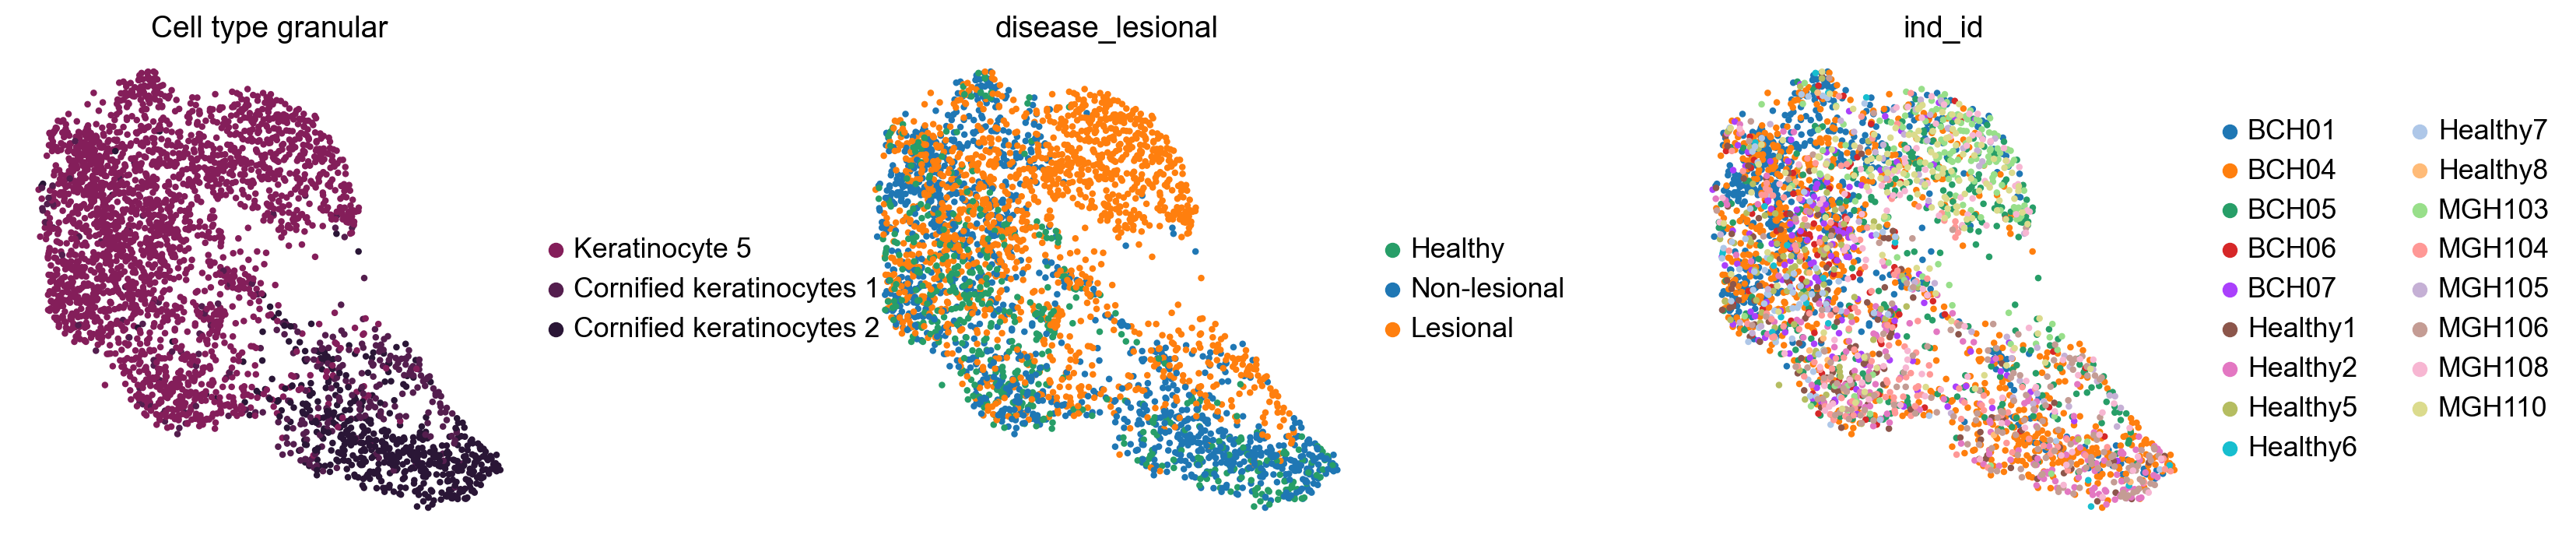

In [117]:
sc.pl.umap(kera, color=['Cell type granular', 'disease_lesional', 'ind_id'], wspace=0.5, frameon=False)

sc.tl.rank_genes_groups(kera, 'leiden', use_raw=False)

sc.pl.rank_genes_groups(kera, sharey=False)

In [132]:
%%time 

process = True

if process:

    velo = sc.read('AtopicDermatitis-with-velo-v2.h5ad')
    velo = velo[kera.obs_names].copy()

    velo.obsm['X_umap'] = kera.obsm['X_umap']
    velo.obsm['X_harmony'] = kera.obsm['X_harmony']
    velo.obs['Cell type granular'] = kera.obs['Cell type granular']
    #velo.uns['Cell type granular_colors'] = kera.uns['Cell type granular_colors']

    #scv.pp.neighbors(velo, use_rep='X_harmony', n_neighbors=30)
    scv.pp.neighbors(velo, n_neighbors=100)

    scv.tl.diffmap(velo)

    velo.layers['scaled'] = velo.X.copy()
    sc.pp.scale(velo, layer='scaled')

    velo_unfiltered = velo.copy()
    #velo_unfiltered.write('keratinocytes-diffmap-dynamical-velo-unfiltered.h5ad')
    
    velo.X = velo.layers['counts'].copy()

    scv.pp.filter_genes(velo) #, min_shared_counts=20)
    scv.pp.normalize_per_cell(velo)
    scv.pp.filter_genes_dispersion(velo, n_top_genes=1000)
    scv.pp.log1p(velo)

    scv.pp.moments(velo)

    #scv.tl.recover_dynamics(velo, n_jobs=8)
    scv.tl.velocity(velo) #, mode='dynamical')
    scv.tl.velocity_graph(velo)
    
    #velo.write('keratinocytes-diffmap-dynamical-velo.h5ad')
    
else:
    velo = sc.read('keratinocytes-diffmap-dynamical-velo-unfiltered.h5ad')
    velo_unfiltered = sc.read('keratinocytes-diffmap-dynamical-velo-unfiltered.h5ad')    

computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
Normalized count data: X, spliced, unspliced.
Extracted 1000 highly variable genes.
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/128 cores)


  0%|          | 0/3192 [00:00<?, ?cells/s]

    finished (0:00:05) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
CPU times: user 11.3 s, sys: 3.57 s, total: 14.9 s
Wall time: 14.8 s


In [133]:
kera.uns['Cell type granular_colors']

array(['#841e5a', '#541e4e', '#2a1636'], dtype=object)

In [134]:
velo.uns['Cell type granular_colors'] = kera.uns['Cell type granular_colors']
velo.uns['Cell type granular_colors'] = ['#C1AEBE', '#8a3444', '#2a1636']

In [135]:
#velo.obs['Cell type granular'].cat.rename_categories(['KC 5', 'Cornified KC 1', 'Cornified KC 2'], inplace=True)

In [136]:
%matplotlib inline

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
saving figure to file ./figures/scvelo_kc-velocity-tests.svg


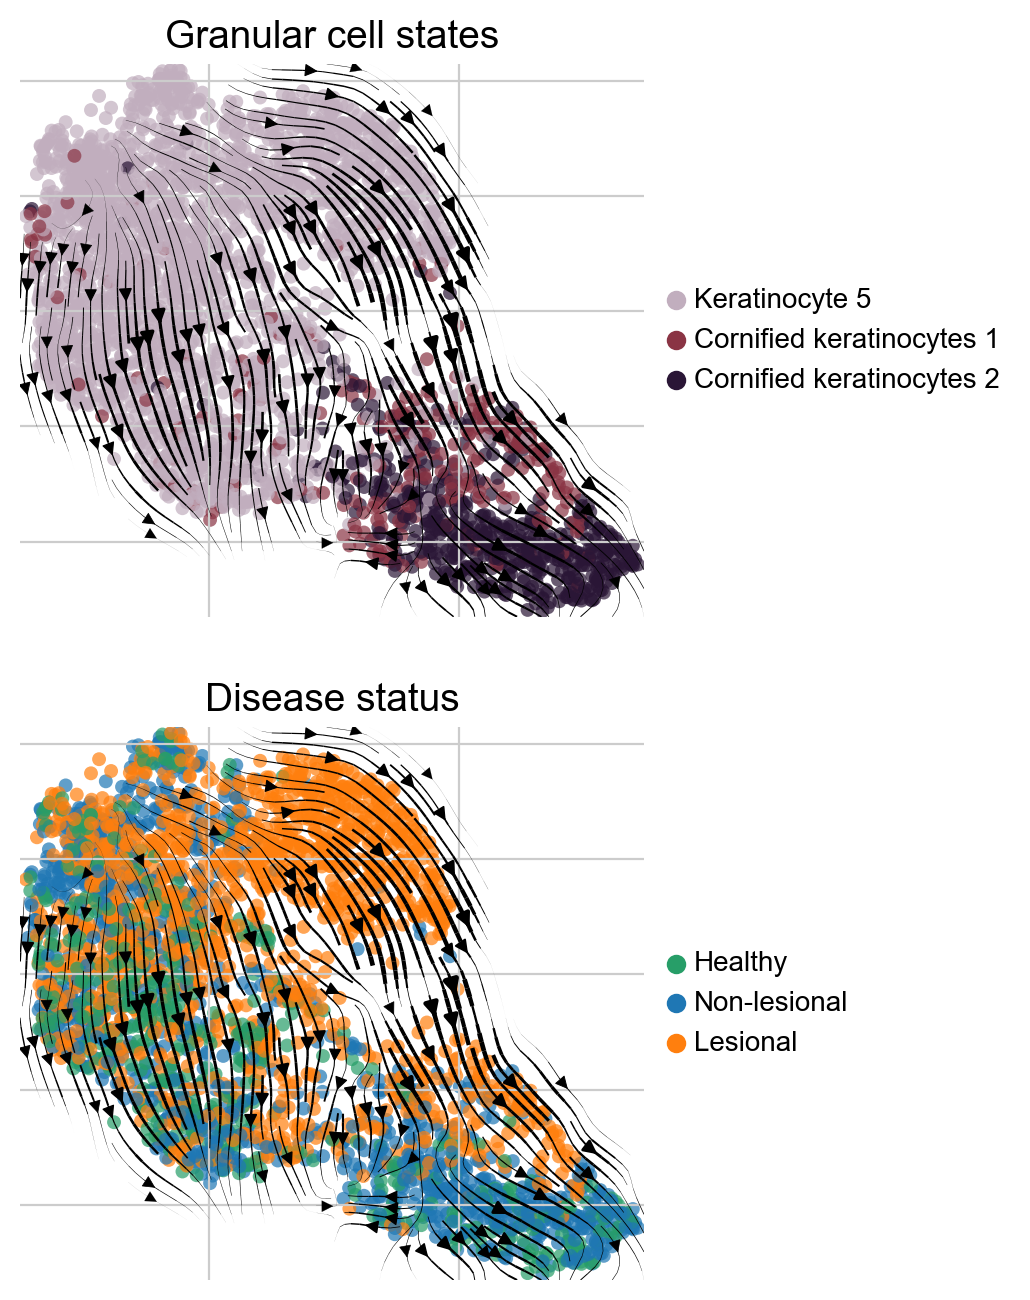

In [137]:
scv.pl.velocity_embedding_stream(velo, basis='umap', legend_fontweight='normal', legend_fontsize=10, figsize=(4,4), legend_loc='right margin', size=100, color=['Cell type granular', 'disease_lesional'], alpha=.7, smooth=1., ncols=1, title=['Granular cell states', 'Disease status'], save='kc-velocity-tests.svg')

In [156]:
velo.obs['key'] = velo.obsm['X_umap'][:, 1]*(-velo.obsm['X_umap'][:, 0])

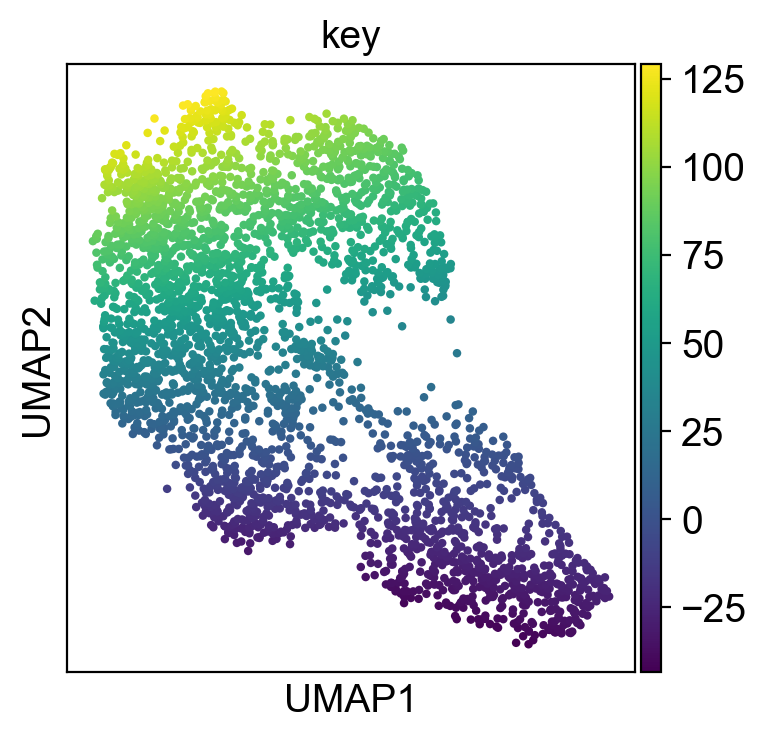

In [157]:
sc.pl.umap(velo, color='key')

In [216]:
velo.uns['iroot'] = np.argmax(velo.obsm['X_umap'][:, 1]*(-velo.obsm['X_umap'][:, 0]))

In [218]:
sc.tl.diffmap(velo)

In [219]:
sc.tl.dpt(velo)

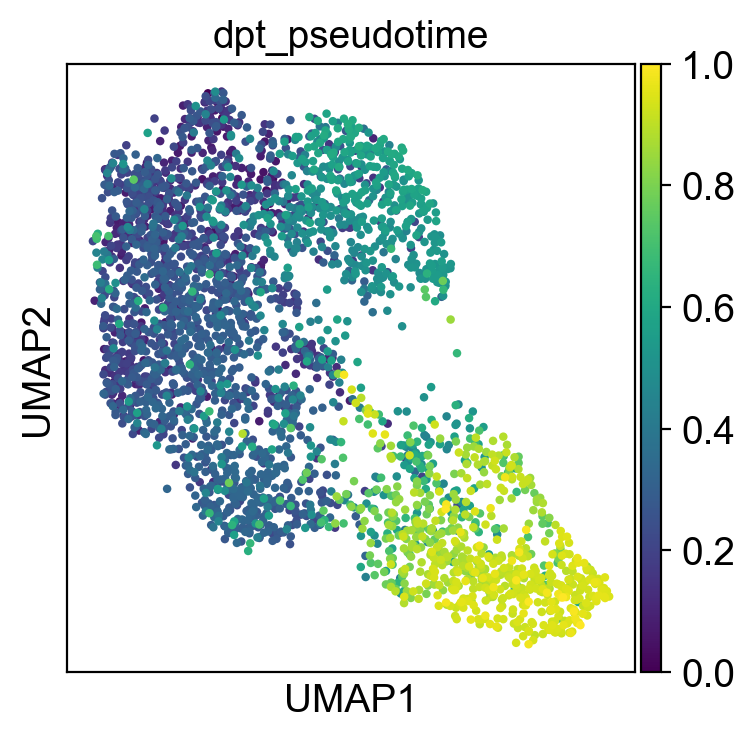

In [220]:
sc.pl.umap(velo, color='dpt_pseudotime')

In [221]:
velo.obs['ctmerged'] = velo.obs['Cell type granular'].astype(str).copy()
velo.obs['ctmerged'].loc[velo.obs['ctmerged'].str.startswith('Cornified')] = 'Cornified KC'
velo._sanitize()
velo.obs.ctmerged.cat.reorder_categories(['Keratinocyte 5', 'Cornified KC'], inplace=True)

... storing 'ctmerged' as categorical


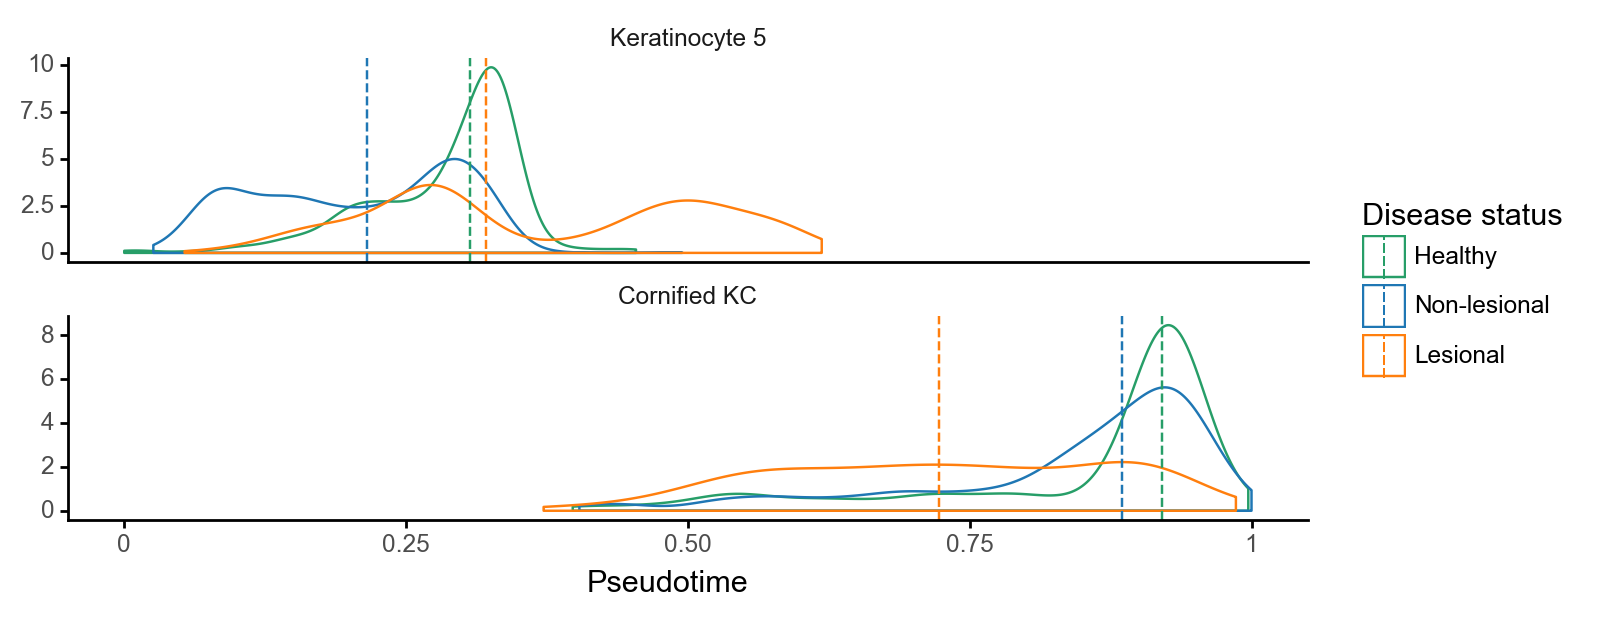

<ggplot: (8766590319689)>

In [223]:
df = velo.obs[['dpt_pseudotime', 'disease_lesional', 'ctmerged']]
df['dpt_rank'] = np.argsort(np.argsort(df.dpt_pseudotime)).astype(float)
#df['Cell type granular'] = df['Cell type granular'].map({'DC2': 'DC2', 'mmDC LAMP3+': 'mmDC', 'DC MMP12 hi LAMP3 lo': 'DC MMP12+'})

import plotnine as p9

f = (p9.ggplot(p9.aes(x='dpt_pseudotime', color='disease_lesional'), df) + 
    #p9.geom_point(size=0.1) + 
    #p9.geom_smooth(method='loess', color='#555555', se=False) +
    #p9.geom_path() + 
    #p9.geom_rug() +
    p9.geom_density(trim=True) +
    p9.geom_vline(p9.aes(xintercept='dpt_pseudotime', color='disease_lesional'), linetype='dashed', data=df.groupby(['disease_lesional', 'ctmerged']).median().reset_index()) +
    p9.theme_classic() + 
    p9.facet_wrap('ctmerged', scales='free_y', ncol=1) + 
    p9.theme(figure_size=(8,3), panel_spacing_x=0.5, text=p9.element_text(family='Arial'), strip_background=p9.element_blank()) + 
    p9.labs(x='Pseudotime', y='', color='Disease status') +
    p9.scale_x_continuous(limits=[0, 1]) +
    p9.scale_color_manual(velo.uns['disease_lesional_colors'])     
)

p9.ggsave(f, 'figures/Figure2/KC-traj-densities-3state-merged-cKC.pdf')

f 

In [224]:
from scipy.stats import ttest_ind, mannwhitneyu, ks_2samp

In [228]:
res = []

print('\tHvsL')
for ct in df['ctmerged'].cat.categories:

    x = df[(df.disease_lesional == 'Healthy') & (df['ctmerged'] == ct)].dpt_pseudotime
    y = df[(df.disease_lesional == 'Lesional') & (df['ctmerged'] == ct)].dpt_pseudotime

    print(ct)
    print(mannwhitneyu(x, y))
    print(ks_2samp(x, y))
    
    res.append(['HvsL', ct, ks_2samp(x, y).pvalue])

	HvsL
Keratinocyte 5
MannwhitneyuResult(statistic=160081.0, pvalue=5.7133437486669375e-11)
KstestResult(statistic=0.4471586636588248, pvalue=6.661338147750939e-16)
Cornified KC
MannwhitneyuResult(statistic=16677.0, pvalue=7.278338216029134e-17)
KstestResult(statistic=0.5068493150684932, pvalue=1.9744140796059703e-17)


In [229]:
res = []

print('\tHvsNL')
for ct in df['ctmerged'].cat.categories:

    x = df[(df.disease_lesional == 'Healthy') & (df['ctmerged'] == ct)].dpt_pseudotime
    y = df[(df.disease_lesional == 'Non-lesional') & (df['ctmerged'] == ct)].dpt_pseudotime

    print(ct)
    print(mannwhitneyu(x, y))
    print(ks_2samp(x, y))
    
    res.append(['HvsL', ct, ks_2samp(x, y).pvalue])

	HvsNL
Keratinocyte 5
MannwhitneyuResult(statistic=191484.0, pvalue=1.4441320763458428e-45)
KstestResult(statistic=0.3953968234777317, pvalue=1.64981285772213e-32)
Cornified KC
MannwhitneyuResult(statistic=41293.0, pvalue=0.017564501664353936)
KstestResult(statistic=0.25574877641976324, pvalue=5.306837292939903e-07)


In [230]:
res = []

print('\tNLvsL')
for ct in df['ctmerged'].cat.categories:

    x = df[(df.disease_lesional == 'Non-lesional') & (df['ctmerged'] == ct)].dpt_pseudotime
    y = df[(df.disease_lesional == 'Lesional') & (df['ctmerged'] == ct)].dpt_pseudotime

    print(ct)
    print(mannwhitneyu(x, y))
    print(ks_2samp(x, y))
    
    res.append(['HvsL', ct, ks_2samp(x, y).pvalue])

	NLvsL
Keratinocyte 5
MannwhitneyuResult(statistic=210241.0, pvalue=1.135781556429257e-109)
KstestResult(statistic=0.47198108578311104, pvalue=2.6645352591003757e-15)
Cornified KC
MannwhitneyuResult(statistic=53853.0, pvalue=3.487051869991049e-18)
KstestResult(statistic=0.41860115385667024, pvalue=1.4432899320127035e-15)
